In [1]:
#Setting up the Environment

import os
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Data Import

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#This cell updates result list for images with tumour
encoder = OneHotEncoder()
encoder.fit([[0],[1]])

data=[]
paths=[]
result=[]

for r,d,f in os.walk(r"/content/drive/My Drive/dataset/yes"):
  for file in f:
    if '.jpg' in file:
      paths.append(os.path.join(r,file))

for path in paths:
  img=Image.open(path)
  img=img.resize((128,128))
  img=np.array(img)

  if(img.shape==(128,128,3)):
    data.append(np.array(img))
    result.append(encoder.transform([[0]]).toarray())

      #The label 0 is transformed into[1,0]
      #The label 1 is transformed into [0,1]

In [4]:
#this cell updates the result list for images without tumor

paths=[]
for r,d,f in os.walk(r"/content/drive/My Drive/dataset/no"):
  for file in f:
    if ".jpg" in file:
      paths.append(os.path.join(r,file))

for path in paths:
  img=Image.open(path)
  img=img.resize((128,128))
  img=np.array(img)


  if (img.shape==(128,128,3)):
    data.append(np.array(img))
    result.append(encoder.transform([[1]]).toarray())

In [5]:
data=np.array(data)
print(data.shape)
print(f"Total number of images we have:{len(data)}")

(139, 128, 128, 3)
Total number of images we have:139


Splitting the data into training and testing

In [6]:
result = np.array(result)
result = np.squeeze(result)
print(result.shape)

(139, 2)


In [7]:
x_train, x_test, y_train, y_test=train_test_split(data, result, test_size=0.2,shuffle=True)

In [8]:
print(f"Number of Images in training data {len(x_train)}")

Number of Images in training data 111


In [9]:
print(f"Number of images in testing data {len(x_test)}")

Number of images in testing data 28


Building AI model

In [10]:
model=Sequential()

#Filtering Layer 32 filter with size 2x2
model.add(Conv2D(32, kernel_size=(2,2), input_shape=(128,128,3), padding='Same'))
model.add(Conv2D(32, kernel_size=(2,2), activation='relu', padding='Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(2,2), activation='relu', padding="Same"))
model.add(Conv2D(64, kernel_size=(2,2), activation='relu', padding="Same"))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))



#Flatten layer
model.add(Flatten())

#Fully connected layer
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2, activation='softmax'))

model.compile(loss="categorical_crossentropy", optimizer="Adamax",  metrics=['accuracy'])
print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,585,602 (128.12 MB)

 Trainable params: 33,585,410 (128.12 MB)

 Non-trainable params: 192 (768.00 B)

None


Model Evaluation

---



---



---



---



In [11]:
history=model.fit(x_train, y_train, epochs=30, batch_size=40, verbose=1, validation_data=(x_test, y_test))

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.5766 - loss: 62.5227 - val_accuracy: 0.7143 - val_loss: 20.1245
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.7117 - loss: 17.6359 - val_accuracy: 0.5714 - val_loss: 18.4354
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.8018 - loss: 6.3202 - val_accuracy: 0.5357 - val_loss: 10.3056
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6667 - loss: 4.4884 - val_accuracy: 0.5714 - val_loss: 7.3820
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.8378 - loss: 1.3562 - val_accuracy: 0.7143 - val_loss: 3.8286
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8649 - loss: 1.0880 - val_accuracy: 0.6786 - val_loss: 4.6562
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.8649 - loss: 0.9547 - val_accuracy: 0.7143 - val_loss: 3.0685
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.9550 - loss: 0.2625 - val_accuracy: 0.8214 - val_loss: 2.2541
Epo

In [12]:
x_train=np.array(x_train)
print(x_train.shape)
y_train=np.array(y_train)
print(y_train.shape)

(111, 128, 128, 3)
(111, 2)


In [13]:
print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))


1.0
0.8571428656578064


In [14]:
print(result.shape)

(139, 2)


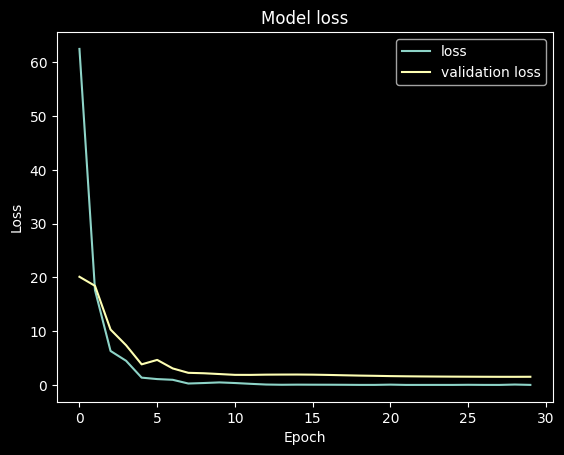

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["loss", "validation loss"], loc='upper right')
plt.savefig("Model_loss.png")
plt.show()

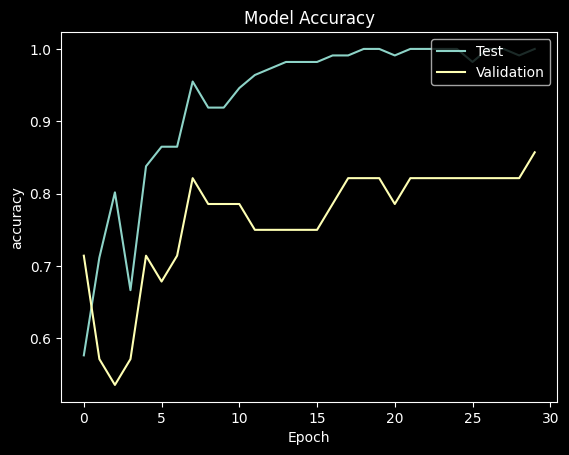

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("accuracy")
plt.xlabel("Epoch")
plt.legend(["Test", "Validation"], loc='upper right')
plt.show()

Testing the model


In [17]:
def names(number):
  if number==0:
    return 'Its a Tumour'
  else:
    return "No, Its not a tumour"

98.54079%Confidence No, Its not a tumour


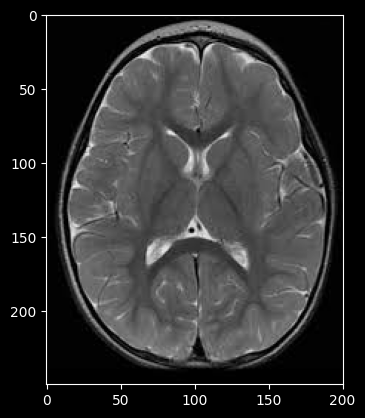

In [18]:
from matplotlib.pyplot import imshow
img=Image.open(r"/content/drive/My Drive/dataset/no/N5.jpg")
X=np.array(img.resize((128,128)))
x=X.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification=np.where(res==np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+'%Confidence ' +names(classification))

97.26486% Confidence Yes Its a Tumour


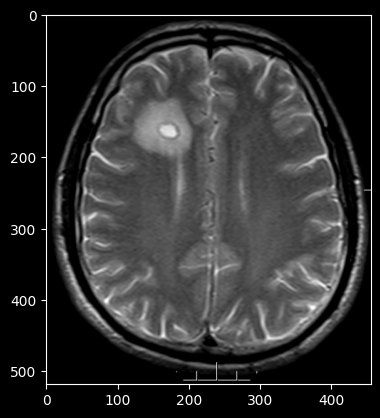

In [19]:
from matplotlib.pyplot import imshow
img = Image.open(r"/content/drive/My Drive/dataset/yes/Y3.jpg")
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence Yes ' + names(classification))

In [31]:
#@title Provide a title for the app
heading_title="Brain Tumor Detection Application" #@param{type:"string"}

In [32]:
#@title Add some examples that we want to be present in our app
num_examples=2 # @param{type:"slider", min:1, max:6, step:1}

example_path_1: /content/drive/My Drive/dataset/no/N5.jpg
example_path_2: /content/drive/My Drive/dataset/yes/Y3.jpg


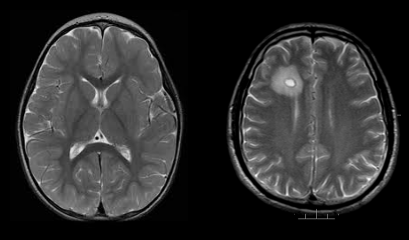

In [33]:
#@title Enter the paths for the example  images

from matplotlib import pyplot as plt
from PIL import Image

examples=[]

for i in range(num_examples):
  example_path=input(f"example_path_{i+1}: ")
  examples.append(example_path)

#Displaying the selected images side by side
rows=1
plt.figure(figsize=(16,8))
for num ,x in enumerate(examples):
  img=Image.open(x)
  plt.subplot(rows, 6, num+1)
  #plt.title(x.split(".")[0])
  plt.axis("off")
  plt.imshow(img)



In [36]:
#@title Adding some description
desc="Brain tumor app. Let's Learn" #@param{type:"string"}
long_desc="Select an image or upload one to predict if brain tumour is present or not" # @param {type:"string"}

In [37]:
import gradio as gr
#@title Select a Theme for Gradio Interface:
theme_selection="Base" # @param["Base","default","Glass"]

theme_dict={
    "Base":gr.themes.Base(),
    "Default":gr.themes.Default(),
    "Glass":gr.themes.Glass(),
    "Monochrome":gr.themes.Monochrome(),
    "Soft":gr.themes.Soft()
}

# The selected theme is determined by the user's dropdown selection
selected_theme=theme_dict[theme_selection]



In [38]:
def recognize_image(image):
    # Resize the image to the expected dimensions
    img = Image.fromarray(image).resize((128, 128))
    # Convert the image to a NumPy array
    x = np.array(img)
    # Reshape the image to match the model input
    x = x.reshape(1, 128, 128, 3)

    # Make a prediction
    res = model.predict_on_batch(x)
    classification = np.where(res == np.amax(res))[1][0]

    # Map the class index to the actual class name (assuming you have a list of class names)
    class_names = ['No Tumor', 'Tumor']  # Example class names, update according to your model
    result = f"{names(classification)}"

    return result

In [ ]:
# Assuming recognize_image, examples, heading_title, desc, long_desc, and selected_theme are defined elsewhere.

# Update the import for components
image = gr.Image()
label = gr.Label()

# Create the interface with the updated component imports
iface = gr.Interface(
    fn=recognize_image,
    inputs=image,
    outputs=label,
    examples=examples,
    title=heading_title,
    description=desc,
    article=long_desc,
    theme=selected_theme  # Make sure this is defined based on user selection as explained in previous messages
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d910266cdd72b5cfa4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
